# Protein folding (Baldo's version)
This follows everything Baldo teached and said the exam was going to be about. It manages everything, downloads the databases, pdb files and run's the programs. In each cell there are instructions for fine tunning the parameters of the programs, but the default ones should be good enough for the exam.

## PSI-BLAST and HMM
This notebook is to create a pipeline for Baldo's exam lol.

In [1]:
from src.Homology import *
from src.Homology.retrieve import *
from src.UI.app import *
from src.Homology.domains import *
import pandas as pd
import matplotlib.pyplot as plt
import py3Dmol

Retrieve will run psi-blast and the HMM using the fasta sequence of the target protein.
You need to put the target fasta sequence in the `target/` folder, the name doesn't matter but there should be only one file!. 
The output of psi-blast will be stored in `temp/target_psiblast.out` and the HMM output will be stored in `temp/target_hmm.out`.

This is ordered based on the Bitscore and E-value

In [2]:
x = Retrieve(e_value_threshold=1e-5, num_iterations=5, num_hits=20)
x.homologs

,PDB_ID,Bitscore,E-value,Identity,Query_Coverage,Query_Start,Query_End,Subject_Start,Subject_End,Query_Length,Protein Name,Organism,Origin
0,9H0M_B,222.0,1.840000e-75,15.278,98,1,141,4,147,144,HEMOGLOBIN SUBUNIT BETA,Gallus gallus,MSA-based Search
1,1HBR_B,222.0,2.300000e-75,15.278,98,1,141,3,146,144,PROTEIN (HEMOGLOBIN D),Gallus gallus,MSA-based Search
2,2QMB_B,221.0,3.520000e-75,15.972,98,1,141,3,146,144,HEMOGLOBIN BETA CHAIN,Meleagris gallopavo,MSA-based Search
3,3MJP_B,221.0,5.000000e-75,15.278,98,1,141,3,146,144,HEMOGLOBIN SUBUNIT BETA,Coturnix japonica,MSA-based Search
4,1FAW_B,221.0,6.020000e-75,15.278,98,1,141,3,146,144,HEMOGLOBIN (BETA SUBUNIT),Anser anser,MSA-based Search
...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,1CP5_A,45.1,5.650000e-06,13.103,97,1,140,3,147,144,PROTEIN (MYOGLOBIN),Physeter macrocephalus,MSA-based Search
769,4OOD_A,45.1,5.700000e-06,12.414,97,1,140,3,147,144,MYOGLOBIN,Physeter macrocephalus,MSA-based Search
770,1OJ6_A,45.1,6.200000e-06,13.986,93,5,138,5,146,144,NEUROGLOBIN,Homo sapiens,MSA-based Search
771,6OTW_A,44.7,6.480000e-06,24.658,97,1,139,4,147,144,HEMOGLOBIN II,Phacoides pectinatus,MSA-based Search


# Obtener los dominios de la proteína objetivo, importante al parecer

# Select the number of templates to visualize.
This is important so it can show you the domains of the templates, coverage and superimposition of the templates. Change the value of the variable `num_templates` to select the number of templates to visualize in the next cell. The default value is 5, but you can change it to any number you want (but not too high, otherwise it will be hard to visualize).
Later you can select the specific templates you want to use for the Modeling part of the exam, but for now just select the number of templates you want to visualize.

In [3]:
num_templates = 5

# Domains and superimposition of the templates
This is important to see the coverage of the templates, if they cover the same domains or different ones, and if they have the same domains as the target protein. This will help you to select the templates for the Modeling part of the exam.

In [ ]:

template_proc = TemplateProcessor(x.homologs, number_of_templates=num_templates)

In [5]:

my_target = ["My_Target_Seq", f"{template_proc.target_sequence}", [{'id': '...', 'name': 'Target Domain', 'start': 10, 'end': 50}]]
viewer = DomainVisualizer(my_target, template_proc.domain_data)
viewer.show()

# Domains of the templates
This is important to see the coverage of the templates, if they cover the same domains or different ones, and if they have the same domains as the target protein. This will help you to select the templates for the Modeling part of the exam.

## Visualize the Do

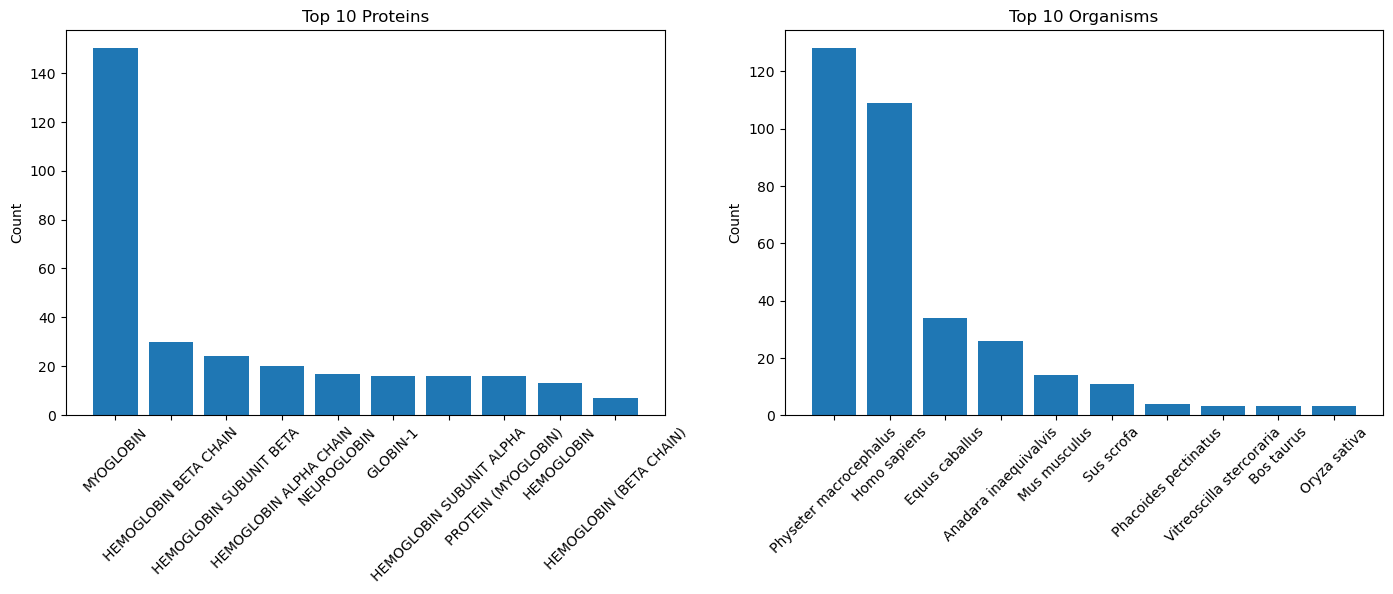

In [10]:
x.plot_homologs()

# Select the number of templates to visualize.
Change the value of the variable `num_templates` to select the number of templates to visualize in the next cell. The default value is 5, but you can change it to any number you want (but not too high, otherwise it will be hard to visualize).
Later you can select the specific templates you want to use for the Modeling part of the exam, but for now just select the number of templates you want to visualize.

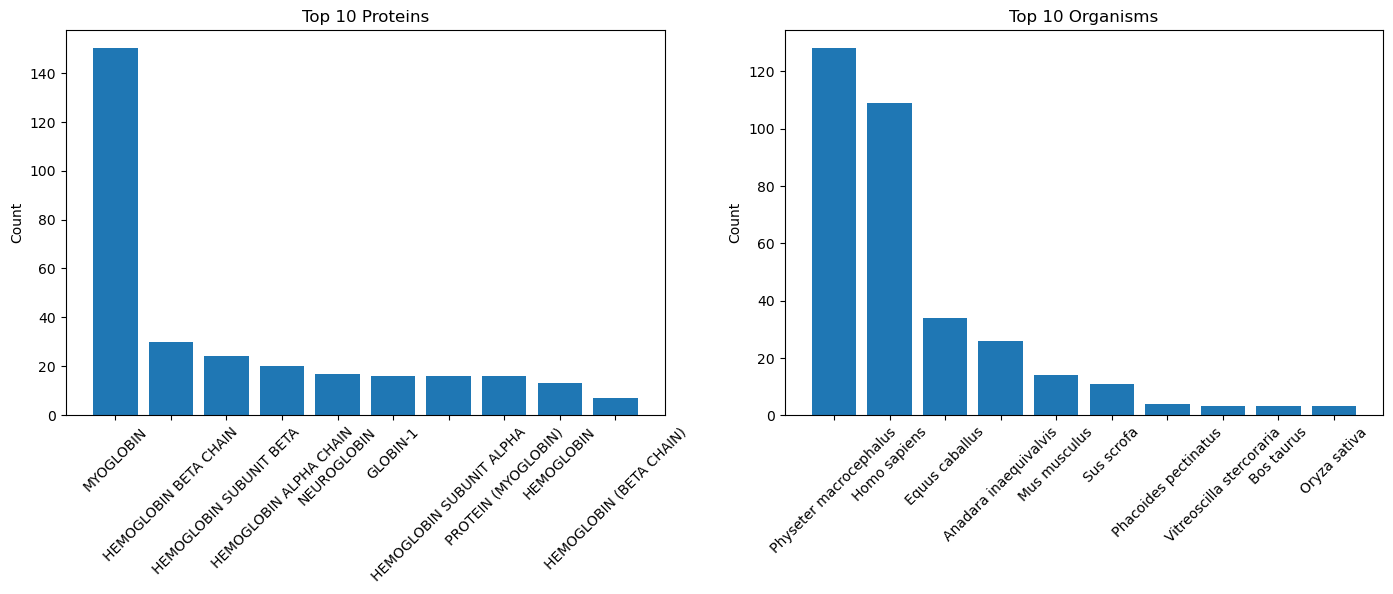

In [ ]:
from Bio.PDB import Superimposer, PDBIO
from Bio import SeqIO
from Bio.PDB import PDBParser
import io

class Superimposer:
    def __init__(self, homologs):
        self.si = Superimposer()

def get_ca_mapping(pdb_id, msa_seq):
    pdb_id, chain_id = pdb_id.split("_")[0], pdb_id.split("_")[1]
    pdb_file = Path("Templates") / f"pdb{pdb_id.lower()}.ent"
    
    parser = PDBParser(QUIET=True)
    structure = parser.get_structure(pdb_id, pdb_file)
    chain = structure[0][chain_id]



    ca_atoms = [res['CA'] for res in chain.get_residues() if res.has_id('CA')]
    alignment = list(SeqIO.parse("Alignments/aligned_templates.fasta", "fasta"))
    print(alignment)
    aligned_target = next(rec.seq for rec in alignment if rec.id == pdb_id + "_" + chain_id)
    aligned_template = next(rec.seq for rec in alignment if rec.id == "GLB1_CALSO")

    mapping = {}
    target_idx = 0 
    atom_idx = 0   
    
    for t_char, p_char in zip(aligned_target, aligned_template):        
        if t_char != '-' and p_char != '-':
            if atom_idx < len(ca_atoms):
                mapping[target_idx] = ca_atoms[atom_idx]
        
        if t_char != '-':
            target_idx += 1 
        if p_char != '-':
            atom_idx += 1   
            
    return mapping, structure

def superimpose_structures(target_structure, template_structure, mapping):
    target_atoms = [mapping[i] for i in sorted(mapping.keys())]
    template_atoms = [mapping[i] for i in sorted(mapping.keys())]

    print(target_atoms)
    print(template_atoms)

mapping, structure = get_ca_mapping(x.homologs["PDB_ID"][1], "Alignments/aligned_templates.fasta")
superimpose_structures()

[SeqRecord(seq=Seq('--VSANDIKNVQDTWGKLYDQWDAVHASKFYNKLFKDSEDISEAFVKAGTGSGI...TVA'), id='GLB1_CALSO', name='GLB1_CALSO', description='GLB1_CALSO', dbxrefs=[]), SeqRecord(seq=Seq('VHWTAEEKQLITGLWGKVNVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAI...---'), id='9H0M_B', name='9H0M_B', description='9H0M_B', dbxrefs=[]), SeqRecord(seq=Seq('VHWTAEEKQLITGLWGKVNVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAI...---'), id='1HBR_B', name='1HBR_B', description='1HBR_B', dbxrefs=[]), SeqRecord(seq=Seq('VHWSAEEKQLITGLWGKVNVADCGAEALARLLIVYPWTQRFFASFGNLSSPTAI...---'), id='2QMB_B', name='2QMB_B', description='2QMB_B', dbxrefs=[]), SeqRecord(seq=Seq('VHWSAEEKQLITGLWGKVNVAECGAEALARLLIVYPWTQRFFASFGNLSSPTAI...---'), id='3MJP_B', name='3MJP_B', description='3MJP_B', dbxrefs=[]), SeqRecord(seq=Seq('VHWSAEEKQLITGLWGKVNVADCGAEALARLLIVYPWTQRFFSSFGNLSSPTAI...---'), id='1FAW_B', name='1FAW_B', description='1FAW_B', dbxrefs=[])]


({2: <Atom CA>,
  3: <Atom CA>,
  4: <Atom CA>,
  5: <Atom CA>,
  6: <Atom CA>,
  7: <Atom CA>,
  8: <Atom CA>,
  9: <Atom CA>,
  10: <Atom CA>,
  11: <Atom CA>,
  12: <Atom CA>,
  13: <Atom CA>,
  14: <Atom CA>,
  15: <Atom CA>,
  16: <Atom CA>,
  17: <Atom CA>,
  18: <Atom CA>,
  19: <Atom CA>,
  20: <Atom CA>,
  21: <Atom CA>,
  22: <Atom CA>,
  23: <Atom CA>,
  24: <Atom CA>,
  25: <Atom CA>,
  26: <Atom CA>,
  27: <Atom CA>,
  28: <Atom CA>,
  29: <Atom CA>,
  30: <Atom CA>,
  31: <Atom CA>,
  32: <Atom CA>,
  33: <Atom CA>,
  34: <Atom CA>,
  35: <Atom CA>,
  36: <Atom CA>,
  37: <Atom CA>,
  38: <Atom CA>,
  39: <Atom CA>,
  40: <Atom CA>,
  41: <Atom CA>,
  42: <Atom CA>,
  43: <Atom CA>,
  44: <Atom CA>,
  45: <Atom CA>,
  46: <Atom CA>,
  47: <Atom CA>,
  48: <Atom CA>,
  49: <Atom CA>,
  50: <Atom CA>,
  51: <Atom CA>,
  52: <Atom CA>,
  53: <Atom CA>,
  54: <Atom CA>,
  55: <Atom CA>,
  56: <Atom CA>,
  57: <Atom CA>,
  58: <Atom CA>,
  59: <Atom CA>,
  60: <Atom CA>,
  61:

In [9]:
x.homologs["PDB_ID"][1]

'1HBR'

In [5]:
a = CoverageVisualizer(x.homologs, number_of_templates=5)
a.show()

In [ ]:
a.aligned_target

In [ ]:
import os
from pathlib import Path
import ipywidgets as widgets
from IPython.display import display, HTML
from Bio import SeqIO

class CoverageVisualizer:
    def __init__(self, templates_df, number_of_templates=2):
        # 1. Load the Target Sequence
        self.target_path = Path("target") / os.listdir("target")[0]
        self.target_fasta = SeqIO.read(self.target_path, "fasta")
        self.target_sequence = str(self.target_fasta.seq)
        self.target_length = len(self.target_sequence)

        self.sliders = {}
        self.template_data = {} # Store sequences and colors to use in the HTML renderer
        
        # Color palette for highlighting different templates
        self.bg_colors = ['#ADD8E6', '#90EE90', '#FFB6C1', '#FFE4B5', '#D3D3D3'] 

        top_templates = templates_df.head(number_of_templates) if hasattr(templates_df, 'head') else templates_df[:number_of_templates]

        # 2. Dynamically create sliders
        for i, template in top_templates.iterrows(): 
            letter = chr(65 + i)
            color = self.bg_colors[i % len(self.bg_colors)]
            self.create_slider(letter, template, color)

        # 3. Create an HTML widget for our visual output
        self.html_output = widgets.HTML()

    def create_slider(self, letter, template, color):
        qstart = int(template.get('qstart', 1))
        qend = int(template.get('qend', self.target_length))
        pdb_id = template.get('PDB_ID', 'Unknown')
        
        # IMPORTANT: Assuming you have the aligned template sequence in your data
        # If it's missing, we create a mock one for testing UI functionality
        mock_seq = "A" * self.target_length
        t_seq = template.get('aligned_sequence', mock_seq) 

        # Fix the description truncation using style={'description_width': 'initial'}
        slider = widgets.IntRangeSlider(
            value=[qstart, qend],
            min=1,
            max=self.target_length,
            description=f'Temp {letter} ({pdb_id}):',
            style={'description_width': 'initial'}, 
            continuous_update=True,
            layout=widgets.Layout(width='80%')
        )
        
        self.sliders[letter] = slider
        self.template_data[letter] = {'sequence': t_seq, 'color': color, 'pdb': pdb_id}

    def _update_map(self, **kwargs):
        """Generates HTML to color the sequences based on slider positions."""
        
        # Start building the HTML string
        html = "<div style='font-family: monospace; font-size: 14px; letter-spacing: 2px;'>"
        
        # --- Print the Query Sequence ---
        html += "<h4 style='margin-bottom: 2px;'>Query Sequence</h4>"
        html += f"<div style='padding-bottom: 10px; font-weight: bold;'>{self.target_sequence}</div>"
        
        html += "<h4 style='margin-bottom: 2px;'>Template Alignments</h4>"
        
        # --- Print the Template Sequences ---
        for letter, (start, end) in kwargs.items():
            t_info = self.template_data[letter]
            t_seq = t_info['sequence']
            bg_color = t_info['color']
            
            html += f"<div style='margin-bottom: 5px;'><strong>{letter} ({t_info['pdb']}): </strong>"
            
            # Iterate through the sequence character by character
            for i in range(self.target_length):
                # Ensure we don't crash if the template sequence is shorter than the target
                t_char = t_seq[i] if i < len(t_seq) else '-' 
                q_char = self.target_sequence[i]
                
                # Check if the current position is inside the slider's range (1-indexed to 0-indexed)
                if start - 1 <= i < end:
                    if t_char == q_char:
                        # Match: Color background, standard text
                        html += f"<span style='background-color: {bg_color};'>{t_char}</span>"
                    else:
                        # Mismatch: Color background, RED text
                        html += f"<span style='background-color: {bg_color}; color: red; font-weight: bold;'>{t_char}</span>"
                else:
                    # Outside slider range: Replace with a dot
                    html += f"<span style='color: #a0a0a0;'>.</span>"
                    
            html += "</div>"
            
        html += "</div>"
        
        # Update the HTML widget's value
        self.html_output.value = html

    def show(self):
        # Link the sliders to the update function
        widgets.interactive_output(self._update_map, self.sliders)
        
        # Display sliders on top, HTML visualization on the bottom
        ui = widgets.VBox([self.html_output] + list(self.sliders.values()))
        display(ui)

CoverageVisualizer(x.homologs, number_of_templates=5).show()

In [ ]:
x.download_templates()

In [ ]:
import ipywidgets as widgets
from IPython.display import display

target_length = 100 
blast_range_a = (10, 80)
blast_range_b = (60, 95)

# 2. Create the Sliders
slider_a = widgets.IntRangeSlider(
    value=blast_range_a, min=1, max=target_length, 
    description='Template A:', continuous_update=True
)

slider_b = widgets.IntRangeSlider(
    value=blast_range_b, min=1, max=target_length, 
    description='Template B:', continuous_update=True
)

# 3. Define the function that updates the visualization
def visualize_coverage(range_a, range_b):
    # Create an array of dots
    coverage = ['.'] * target_length
    
    # Fill in Template A (using 'A')
    for i in range(range_a[0] - 1, range_a[1]):
        coverage[i] = 'A'
        
    # Fill in Template B (using 'B'). This will overwrite A if they overlap!
    for i in range(range_b[0] - 1, range_b[1]):
        coverage[i] = 'B'
        
    # Join into a string and print
    map_string = "".join(coverage)
    
    print("-" * target_length)
    print(map_string)
    print("-" * target_length)
    
    # Calculate coverage
    missing = coverage.count('.')
    print(f"Coverage: {((target_length - missing) / target_length) * 100:.1f}%")

# 4. Link the sliders to the function and display them!
ui = widgets.interactive(visualize_coverage, range_a=slider_a, range_b=slider_b)
display(ui)

In [ ]:
from modeller import *
from modeller.automodel import *
import py3Dmol
from Bio.Seq import Seq

log.minimal()
env = Environ()

